## This Notebook generates BBN feature importance using full version of the dataset.

## Structure Learning - Bayesian Belief Network

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
from pgmpy.models import BayesianNetwork 
from pgmpy.estimators import HillClimbSearch, BDeu, ExpertKnowledge
from matplotlib.lines import Line2D
from pgmpy.models import DiscreteBayesianNetwork
import matplotlib.patches as mpatches

# ============================================================
# loading data and learning Structure
# ============================================================
DATA_DIR = r"C:\Users\..."
spss_files = glob.glob(os.path.join(DATA_DIR, "*.sav"))

if len(spss_files) == 0:
    raise FileNotFoundError(f"No .sav files found in: {DATA_DIR}")

CLASS_NODE = 'Status'
FIXED = ['Sex', 'Age_cat', 'Smoky']
CHRONIC = ['HTN', 'DM', 'IHD', 'CVA', 'Brain_Tumor', 'BMI_cat']
ACUTE = ['Sofa_Mean_cat', 'Apache_cat', 'Mean_Calcium_cat', 'Mean_Phosphor_cat', 'Mean_Magnesium_cat',
         'Ventilation_Status', 'Pulmonary_Insufficiency', 'Diagnosis']
ALL_FEATURES = FIXED + CHRONIC + ACUTE
ALL_NODES = ALL_FEATURES + [CLASS_NODE]

forbidden_edges = []
for src in ALL_NODES:
    for trg in FIXED: 
        if src != trg: forbidden_edges.append((src, trg)) 
    for trg in CHRONIC:
        if src in ACUTE: forbidden_edges.append((src, trg)) 
    forbidden_edges.append((CLASS_NODE, src)) 

expert_knowledge = ExpertKnowledge(nodes=ALL_NODES, forbidden_edges=forbidden_edges)

all_discovered_edges = []
for file_path in spss_files:
    df_imputed = pd.read_spss(file_path, convert_categoricals=False)
    df_imputed = df_imputed[ALL_NODES]
    hc = HillClimbSearch(data=df_imputed)
    dag_single = hc.estimate(scoring_method=BDeu(data=df_imputed, equivalent_sample_size=10), 
                             expert_knowledge=expert_knowledge)
    all_discovered_edges.extend(list(dag_single.edges()))

edge_counts = Counter(all_discovered_edges)
THRESHOLD = 4
consensus_edges = [edge for edge, count in edge_counts.items() if count >= THRESHOLD]

final_dag = DiscreteBayesianNetwork()
final_dag.add_nodes_from(ALL_NODES)
final_dag.add_edges_from(consensus_edges)

# Extract edges from the final_dag as ordered pairs
edges_list = final_dag.edges()

# Display them as a list of ordered pairs
print("List of ordered pairs (edges)")
for edge in edges_list:
    print(edge)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N', 'Age_cat': 'N', 'Smoky': 'N', 'HTN': 'N', 'DM': 'N', 'IHD': 'N', 'CVA': 'N', 'Brain_Tumor': 'N', 'BMI_cat': 'N', 'Sofa_Mean_cat': 'N', 'Apache_cat': 'N', 'Mean_Calcium_cat': 'N', 'Mean_Phosphor_cat': 'N', 'Mean_Magnesium_cat': 'N', 'Ventilation_Status': 'N', 'Pulmonary_Insufficiency': 'N', 'Diagnosis': 'N', 'Status': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N', 'Age_cat': 'N', 'Smoky': 'N', 'HTN': 'N', 'DM': 'N', 'IHD': 'N', 'CVA': 'N', 'Brain_Tumor': 'N', 'BMI_cat': 'N', 'Sofa_Mean_cat': 'N', 'Apache_cat': 'N', 'Mean_Calcium_cat': 'N', 'Mean_Phosphor_cat': 'N', 'Mean_Magnesium_cat': 'N', 'Ventilation_Status': 'N', 'Pulmonary_Insufficiency': 'N', 'Diagnosis': 'N', 'Status': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N'

  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N', 'Age_cat': 'N', 'Smoky': 'N', 'HTN': 'N', 'DM': 'N', 'IHD': 'N', 'CVA': 'N', 'Brain_Tumor': 'N', 'BMI_cat': 'N', 'Sofa_Mean_cat': 'N', 'Apache_cat': 'N', 'Mean_Calcium_cat': 'N', 'Mean_Phosphor_cat': 'N', 'Mean_Magnesium_cat': 'N', 'Ventilation_Status': 'N', 'Pulmonary_Insufficiency': 'N', 'Diagnosis': 'N', 'Status': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N', 'Age_cat': 'N', 'Smoky': 'N', 'HTN': 'N', 'DM': 'N', 'IHD': 'N', 'CVA': 'N', 'Brain_Tumor': 'N', 'BMI_cat': 'N', 'Sofa_Mean_cat': 'N', 'Apache_cat': 'N', 'Mean_Calcium_cat': 'N', 'Mean_Phosphor_cat': 'N', 'Mean_Magnesium_cat': 'N', 'Ventilation_Status': 'N', 'Pulmonary_Insufficiency': 'N', 'Diagnosis': 'N', 'Status': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N'

  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N', 'Age_cat': 'N', 'Smoky': 'N', 'HTN': 'N', 'DM': 'N', 'IHD': 'N', 'CVA': 'N', 'Brain_Tumor': 'N', 'BMI_cat': 'N', 'Sofa_Mean_cat': 'N', 'Apache_cat': 'N', 'Mean_Calcium_cat': 'N', 'Mean_Phosphor_cat': 'N', 'Mean_Magnesium_cat': 'N', 'Ventilation_Status': 'N', 'Pulmonary_Insufficiency': 'N', 'Diagnosis': 'N', 'Status': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N', 'Age_cat': 'N', 'Smoky': 'N', 'HTN': 'N', 'DM': 'N', 'IHD': 'N', 'CVA': 'N', 'Brain_Tumor': 'N', 'BMI_cat': 'N', 'Sofa_Mean_cat': 'N', 'Apache_cat': 'N', 'Mean_Calcium_cat': 'N', 'Mean_Phosphor_cat': 'N', 'Mean_Magnesium_cat': 'N', 'Ventilation_Status': 'N', 'Pulmonary_Insufficiency': 'N', 'Diagnosis': 'N', 'Status': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N'

  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N', 'Age_cat': 'N', 'Smoky': 'N', 'HTN': 'N', 'DM': 'N', 'IHD': 'N', 'CVA': 'N', 'Brain_Tumor': 'N', 'BMI_cat': 'N', 'Sofa_Mean_cat': 'N', 'Apache_cat': 'N', 'Mean_Calcium_cat': 'N', 'Mean_Phosphor_cat': 'N', 'Mean_Magnesium_cat': 'N', 'Ventilation_Status': 'N', 'Pulmonary_Insufficiency': 'N', 'Diagnosis': 'N', 'Status': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N', 'Age_cat': 'N', 'Smoky': 'N', 'HTN': 'N', 'DM': 'N', 'IHD': 'N', 'CVA': 'N', 'Brain_Tumor': 'N', 'BMI_cat': 'N', 'Sofa_Mean_cat': 'N', 'Apache_cat': 'N', 'Mean_Calcium_cat': 'N', 'Mean_Phosphor_cat': 'N', 'Mean_Magnesium_cat': 'N', 'Ventilation_Status': 'N', 'Pulmonary_Insufficiency': 'N', 'Diagnosis': 'N', 'Status': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N'

  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N', 'Age_cat': 'N', 'Smoky': 'N', 'HTN': 'N', 'DM': 'N', 'IHD': 'N', 'CVA': 'N', 'Brain_Tumor': 'N', 'BMI_cat': 'N', 'Sofa_Mean_cat': 'N', 'Apache_cat': 'N', 'Mean_Calcium_cat': 'N', 'Mean_Phosphor_cat': 'N', 'Mean_Magnesium_cat': 'N', 'Ventilation_Status': 'N', 'Pulmonary_Insufficiency': 'N', 'Diagnosis': 'N', 'Status': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N', 'Age_cat': 'N', 'Smoky': 'N', 'HTN': 'N', 'DM': 'N', 'IHD': 'N', 'CVA': 'N', 'Brain_Tumor': 'N', 'BMI_cat': 'N', 'Sofa_Mean_cat': 'N', 'Apache_cat': 'N', 'Mean_Calcium_cat': 'N', 'Mean_Phosphor_cat': 'N', 'Mean_Magnesium_cat': 'N', 'Ventilation_Status': 'N', 'Pulmonary_Insufficiency': 'N', 'Diagnosis': 'N', 'Status': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Sex': 'N'

  0%|          | 0/1000000 [00:00<?, ?it/s]

List of ordered pairs (edges)
('Sex', 'BMI_cat')
('Age_cat', 'HTN')
('Age_cat', 'Diagnosis')
('Age_cat', 'IHD')
('Age_cat', 'CVA')
('Age_cat', 'DM')
('HTN', 'DM')
('Brain_Tumor', 'Diagnosis')
('Brain_Tumor', 'Pulmonary_Insufficiency')
('Sofa_Mean_cat', 'Apache_cat')
('Sofa_Mean_cat', 'Status')
('Sofa_Mean_cat', 'Ventilation_Status')
('Sofa_Mean_cat', 'Mean_Phosphor_cat')
('Apache_cat', 'Ventilation_Status')
('Ventilation_Status', 'Status')
('Diagnosis', 'Sofa_Mean_cat')
('Diagnosis', 'Pulmonary_Insufficiency')


## Directed Acyclic Graph - DAG

In [ ]:
# ============================================================
# PUBLICATION-QUALITY CONSENSUS BBN FIGURE (EXPANDED SPACING)
# ============================================================

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Publication Style
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 14,
    "axes.linewidth": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

COLOR_MAP = {
    "target": "#C0392B",      # Red
    "fixed": "#4C78A8",       # Blue
    "chronic": "#59A14F",     # Green
    "acute": "#F28E2B"        # Orange
}

node_labels = {
    'Age_cat': 'Age (years)',
    'Sex': 'Gender',
    'Smoky': 'Smoking\nStatus',
    'BMI_cat': 'BMI',
    'HTN': 'Hypertension',
    'DM': 'Diabetes\nMellitus',
    'IHD': 'Ischemic\nHeart\nDisease',
    'CVA': 'Cerebrovascular\nAccident',
    'Brain_Tumor': 'Brain\nTumor',
    'Pulmonary_Insufficiency': 'Pulmonary\nInsufficiency',
    'Apache_cat': 'APACHE II\nScore',
    'Sofa_Mean_cat': 'Mean SOFA\nScore',
    'Mean_Calcium_cat': 'Mean Serum\nCalcium',
    'Mean_Phosphor_cat': 'Mean Serum\nPhosphorus',
    'Mean_Magnesium_cat': 'Mean Serum\nMagnesium',
    'Ventilation_Status': 'Mechanical\nVentilation',
    'Diagnosis': 'Admission\nDiagnosis',
    'Status': 'ICU Mortality'
}

def plot_publication_bbn(dag):
    G = nx.DiGraph()
    G.add_nodes_from(ALL_NODES)
    G.add_edges_from(dag.edges())

    # ========================================================
    # Increasing spacing between layers (Y coordinates expanded to create more separation).
    # ========================================================
    pos = {
        # Layer 1
        'Sex': (2.0, 10.0),
        'Age_cat': (5.0, 10.0),
        'Smoky': (8.0, 10.0),

        # Layer 2
        'BMI_cat': (0.5, 7.5),
        'HTN': (2.2, 7.5),
        'DM': (3.9, 7.5),
        'IHD': (5.6, 7.5),
        'CVA': (7.3, 7.5),
        'Brain_Tumor': (9.0, 7.5),

        # Layer 3
        'Diagnosis': (0.5, 5.0),
        'Apache_cat': (2.5, 5.0),
        'Sofa_Mean_cat': (4.5, 5.0),
        'Ventilation_Status': (6.7, 5.0),
        'Pulmonary_Insufficiency': (9.0, 5.0),

        # Layer 4
        'Mean_Calcium_cat': (2.0, 2.5),
        'Mean_Phosphor_cat': (4.8, 2.5),
        'Mean_Magnesium_cat': (7.5, 2.5),

        # Outcome
        'Status': (4.8, 0.0)
    }

    fig, ax = plt.subplots(figsize=(24, 14), dpi=600, facecolor='white')

    # ========================================================
    # Drawing edges according to the newly reduced box sizes
    # ========================================================
    for edge in G.edges():
        source, target = edge
        if source not in pos or target not in pos:
            continue
            
        x1, y1 = pos[source]
        x2, y2 = pos[target]

        if abs(y1 - y2) < 0.2:
            rad = 0.22  
        else:
            rad = 0.08 if abs(x2 - x1) < 0.8 and abs(y2 - y1) > 1.0 else 0.0

        # Arrow calibration for thin and small updated nodes
        shrink_map = {
            'Diagnosis': 80, 'Ventilation_Status': 75, 'Pulmonary_Insufficiency': 95, 
            'Brain_Tumor': 70, 'Apache_cat': 75, 'Status': 62,
            'Sofa_Mean_cat': 80, 'Mean_Calcium_cat': 60, 'Mean_Phosphor_cat': 60, 'Mean_Magnesium_cat': 60,
            'Age_cat': 65, 'Sex': 55, 'Smoky': 55, 'BMI_cat': 52, 'HTN': 52, 'DM': 72, 'IHD': 52, 'CVA': 72
        }

        shrink_source = shrink_map.get(source, 55) - 15  
        shrink_target = shrink_map.get(target, 55)       

        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(
                arrowstyle="-|>",
                color="#2C3E50",        
                lw=2.6,                 
                shrinkA=shrink_source,  
                shrinkB=shrink_target,  
                mutation_scale=32,  
                connectionstyle=f"arc3,rad={rad}"
            ),
            zorder=1
        )

    # ========================================================
    # Drawing boxes (reduced padding to shrink rectangles physically)
    # ========================================================
    for node, (x, y) in pos.items():
        if node == CLASS_NODE:
            fc = COLOR_MAP["target"]
            ec = "#7B241C"
            txt = "white"
            lw = 3.5
        elif node in FIXED:
            fc = COLOR_MAP["fixed"]
            ec = "#1F4E79"
            txt = "white"
            lw = 2.0
        elif node in CHRONIC:
            fc = COLOR_MAP["chronic"]
            ec = "#1E8449"
            txt = "white"
            lw = 2.0
        else:
            fc = COLOR_MAP["acute"]
            ec = "#AF601A"
            txt = "white"
            lw = 2.0

        ax.text(
            x, y,
            node_labels[node],
            ha='center',
            va='center',
            fontsize=24,          
            fontweight='bold',
            color=txt,
            bbox=dict(
                boxstyle="round,pad=0.3,rounding_size=0.10", 
                fc=fc,
                ec=ec,
                lw=lw
            ),
            zorder=5
        )

    # ========================================================
    #  Legend
    # ========================================================

    legend_elements = [
        Line2D([0], [0], marker='s', color='w', label='Target Outcome', markerfacecolor=COLOR_MAP["target"], markersize=16),
        Line2D([0], [0], marker='s', color='w', label='Demographic Variables', markerfacecolor=COLOR_MAP["fixed"], markersize=16),
        Line2D([0], [0], marker='s', color='w', label='Chronic Comorbidities', markerfacecolor=COLOR_MAP["chronic"], markersize=16),
        Line2D([0], [0], marker='s', color='w', label='Acute ICU Variables', markerfacecolor=COLOR_MAP["acute"], markersize=16)
    ]

    ax.legend(
        handles=legend_elements,
        loc='upper right',
        frameon=True,
        fontsize=14
    )

    # ========================================================
    # Expanding canvas boundaries to fully open up the space and reduce compression
    # ========================================================
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-0.8, 11.2)  
    ax.axis('off')
    plt.tight_layout()
    
    # Standard output generation.
    plt.savefig("Consensus_BBN_Expanded.png", dpi=600, bbox_inches='tight')
    plt.savefig("Consensus_BBN_Expanded.pdf", bbox_inches='tight')
    plt.show()

# Runing final DAG
plot_publication_bbn(final_dag)

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 29 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', 'A', 'C', 'D', 'I', 'O', 'T', 'U', 'V', 'a', 'b', 'c', 'd', 'e', 'g', 'glyph00001', 'glyph00002', 'h', 'i', 'l', 'm', 'n', 'o', 'p', 'r', 's', 'space', 't', 'u']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 36, 38, 39, 44, 50, 55, 56, 57, 68, 69, 70, 71, 72, 74, 75, 76, 79, 80, 81, 82, 83, 85, 86, 87, 88]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 30 glyphs after
INFO:fontTools.subset:Gly

## Conditional Probability Table - CPT

In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import statsmodels.stats.proportion as prop 

# ============================================================
# Initial setup and loading of five imputed datasets
# ============================================================
DATA_DIR = r"C:\Users\imperator\Dropbox\Mace_prediction_SVM\Marzieh Thesis\code\ICU_Phase 2\DATA FOR BBN"
spss_files = glob.glob(os.path.join(DATA_DIR, "*.sav"))

if len(spss_files) == 0:
    raise FileNotFoundError(f"No .sav files found in: {DATA_DIR}")

VAR_1 = 'Sofa_Mean_cat'
VAR_2 = 'Ventilation_Status'
VAR_STATUS = 'Status' 

label_map_sofa = {1.0: 'Low', 2.0: 'Moderate', 3.0: 'High', 4.0: 'Very High', 1: 'Low', 2: 'Moderate', 3: 'High', 4: 'Very High'}
label_map_vent = {1.0: 'No', 2.0: 'Yes', 1: 'No', 2: 'Yes'}

df_sample = pd.read_spss(spss_files[0], convert_categoricals=False)
sofa_states = sorted(df_sample[VAR_1].dropna().unique().tolist())
vent_states = sorted(df_sample[VAR_2].dropna().unique().tolist())

all_cells_data = []

# =============================================================================
# Extraction of frequencies and confidence intervals for mortality and survival
# =============================================================================
for file_path in spss_files:
    df = pd.read_spss(file_path, convert_categoricals=False)
    
    file_results = []
    for sofa in sofa_states:
        for vent in vent_states:
            cell_sub = df[(df[VAR_1] == sofa) & (df[VAR_2] == vent)]
            cell_count = len(cell_sub)
            
            deaths = len(cell_sub[cell_sub[VAR_STATUS] == 1]) if cell_count > 0 else 0
            survivals = len(cell_sub[cell_sub[VAR_STATUS] == 2]) if cell_count > 0 else 0
            
            p_death = deaths / cell_count if cell_count > 0 else 0.0
            p_surv = survivals / cell_count if cell_count > 0 else 0.0
            
            if cell_count > 0:
                ci_death_low, ci_death_high = prop.proportion_confint(deaths, cell_count, alpha=0.05, method='wilson')
                ci_surv_low, ci_surv_high = prop.proportion_confint(survivals, cell_count, alpha=0.05, method='wilson')
            else:
                ci_death_low, ci_death_high = 0.0, 0.0
                ci_surv_low, ci_surv_high = 0.0, 0.0
                
            file_results.append({
                'Sofa_Mean': sofa,
                'Ventilation': vent,
                'Cell_Count': cell_count,
                'Deaths': deaths,
                'Survivals': survivals,
                'P_Death': p_death,
                'CI_Death_Low': ci_death_low,
                'CI_Death_High': ci_death_high,
                'P_Surv': p_surv,
                'CI_Surv_Low': ci_surv_low,
                'CI_Surv_High': ci_surv_high
            })
            
    all_cells_data.append(pd.DataFrame(file_results))

# =============================================================================
# Merging, averaging, and percentage calculations (Rubin’s rules)
# =============================================================================
final_table = all_cells_data[0].copy()

numeric_cols = [
    'Cell_Count', 'Deaths', 'Survivals', 
    'P_Death', 'CI_Death_Low', 'CI_Death_High',
    'P_Surv', 'CI_Surv_Low', 'CI_Surv_High'
]
for col in numeric_cols:
    final_table[col] = 0.0

for df_file in all_cells_data:
    for col in numeric_cols:
        final_table[col] += df_file[col]

for col in numeric_cols:
    final_table[col] /= len(all_cells_data)

# Computation of the total sample size for calculating cell proportions relative to the overall ICU dataset
total_n = final_table['Cell_Count'].sum()

# Creation of a column for total number of patients along with their percentage of the overall sample (in parentheses)
final_table['Total_Patients_in_Cell'] = final_table.apply(
    lambda row: f"{int(round(row['Cell_Count']))} ({(row['Cell_Count']/total_n)*100:.1f}%)", axis=1
)

# Creation of a column for observed deaths along with the mortality rate within each cell (in parentheses)
final_table['Observed_Deaths'] = final_table.apply(
    lambda row: f"{int(round(row['Deaths']))} ({row['P_Death']*100:.1f}%)", axis=1
)

# ============================================================
# Application of labels and final formatting 
# ============================================================
final_table['Sofa_Mean'] = final_table['Sofa_Mean'].map(label_map_sofa).fillna(final_table['Sofa_Mean'])
final_table['Ventilation'] = final_table['Ventilation'].map(label_map_vent).fillna(final_table['Ventilation'])

# Formatting of conditional probability columns and 95% confidence intervals
final_table['Mortality Probability (95% CI)'] = final_table.apply(
    lambda row: f"{row['P_Death']:.3f} ({row['CI_Death_Low']:.3f} to {row['CI_Death_High']:.3f})", axis=1
)
final_table['Survival Probability (95% CI)'] = final_table.apply(
    lambda row: f"{row['P_Surv']:.3f} ({row['CI_Surv_Low']:.3f} to {row['CI_Surv_High']:.3f})", axis=1
)

output_cols = [
    'Sofa_Mean', 
    'Ventilation', 
    'Total_Patients_in_Cell',     
    'Observed_Deaths',               
    'Mortality Probability (95% CI)',
    'Survival Probability (95% CI)'
]
final_report = final_table[output_cols]
print(final_report.to_string(index=False))

# SAVE
final_report.to_csv("cpt_table_3.csv", index=False)

Sofa_Mean Ventilation Total_Patients_in_Cell Observed_Deaths Mortality Probability (95% CI) Survival Probability (95% CI)
      Low          No            394 (43.2%)        2 (0.5%)         0.005 (0.001 to 0.018)        0.995 (0.982 to 0.999)
      Low         Yes             94 (10.3%)      15 (16.0%)         0.160 (0.100 to 0.248)        0.840 (0.752 to 0.900)
 Moderate          No              64 (7.0%)       7 (10.9%)         0.109 (0.054 to 0.208)        0.891 (0.792 to 0.946)
 Moderate         Yes            182 (20.0%)      69 (37.9%)         0.379 (0.311 to 0.451)        0.621 (0.549 to 0.689)
     High          No              19 (2.1%)       7 (36.8%)         0.368 (0.191 to 0.590)        0.632 (0.410 to 0.809)
     High         Yes            101 (11.1%)      71 (70.2%)         0.702 (0.606 to 0.782)        0.298 (0.218 to 0.394)
Very High          No               9 (1.0%)       7 (77.8%)         0.778 (0.453 to 0.937)        0.222 (0.063 to 0.547)
Very High         Yes   

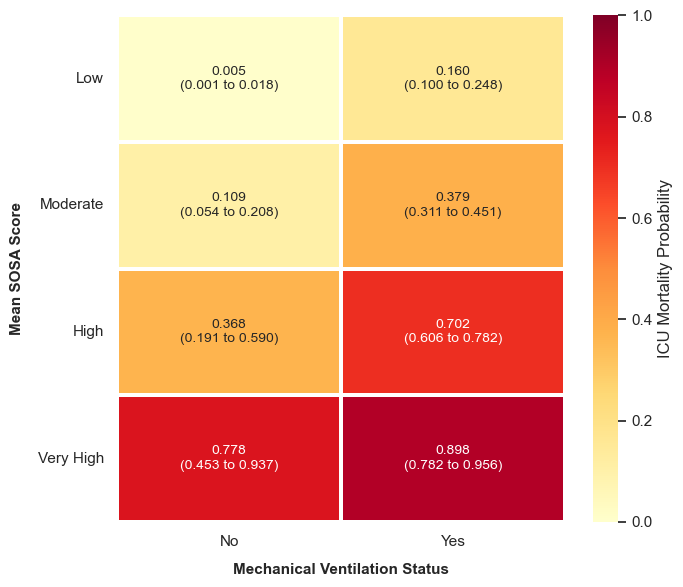

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================================
# Loading final table data (probabilities and confidence intervals)
# ====================================================================
# Label ordering for axes
sofa_labels = ['Low', 'Moderate', 'High', 'Very High']
vent_labels = ['No', 'Yes']

# Mortality probability matrix
prob_matrix = np.array([
    [0.005, 0.160],  # Low SOFA
    [0.109, 0.379],  # Moderate SOFA
    [0.368, 0.702],  # High SOFA
    [0.778, 0.898]   # Very High SOFA
])

# Text-based matrix for simultaneously displaying probabilities and confidence intervals within cells
annot_matrix = np.array([
    ["0.005\n(0.001 to 0.018)", "0.160\n(0.100 to 0.248)"],
    ["0.109\n(0.054 to 0.208)", "0.379\n(0.311 to 0.451)"],
    ["0.368\n(0.191 to 0.590)", "0.702\n(0.606 to 0.782)"],
    ["0.778\n(0.453 to 0.937)", "0.898\n(0.782 to 0.956)"]
])
df_plot = pd.DataFrame(prob_matrix, index=sofa_labels, columns=vent_labels)

# ============================================================
# Chart styling and font settings
# ============================================================
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

fig, ax = plt.subplots(figsize=(7, 6))

# Selection of a standard medical color palette
cmap = sns.color_palette("YlOrRd", as_cmap=True)

# HeatMaap
sns.heatmap(
    df_plot, 
    annot=annot_matrix,           
    fmt="",                       
    cmap=cmap, 
    vmin=0, vmax=1,              
    linewidths=1.5,              
    linecolor='white',           
    cbar_kws={'label': 'ICU Mortality Probability'}, 
    annot_kws={"size": 10, "weight": "medium"},
    ax=ax
)

# ============================================================
# Axis and title configuration
# ============================================================
ax.set_xlabel('Mechanical Ventilation Status', fontsize=11, labelpad=10, weight='bold')
ax.set_ylabel('Mean SOSA Score', fontsize=11, labelpad=10, weight='bold')

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

# ============================================================
# SAVE
# ============================================================
plt.savefig('Mortality_Probability_Heatmap.tiff', dpi=300, format='tiff', bbox_inches='tight')
plt.savefig('Mortality_Probability_Heatmap.png', dpi=300, format='png', bbox_inches='tight')

plt.show()